In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as st



from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn import metrics
from sklearn.linear_model import LinearRegression

# Libraries:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer

In [2]:
mev = pd.read_csv('data.csv')

In [3]:
mev.head()

,COUNTRY,INDICATOR,FREQUENCY,2000,2001,2002,2003,2004,2005,2006,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
0,United Kingdom,"Current account balance (credit less debit), P...",Annual,-1.831,-1.773,-1.973,-1.823,-2.302,-1.998,-3.120,...,-3.493,-3.927,-2.688,-2.934,-0.437,-2.102,-3.509,-2.656,-3.091,-2.961
1,Austria,"Current account balance (credit less debit), P...",Annual,-0.710,-0.800,2.118,1.557,2.092,2.274,3.318,...,1.264,0.846,2.376,3.367,1.735,-0.862,1.341,2.409,1.793,2.157
2,G7,"Current account balance (credit less debit), P...",Annual,-1.361,-1.376,-1.408,-1.481,-1.296,-1.706,-1.860,...,0.090,-0.103,0.039,-0.738,-0.740,-1.992,-1.434,-1.629,-1.757,-1.572
3,United States,"Gross debt, General government, Percent of GDP",Annual,NaN,53.485,55.859,58.956,66.439,65.778,64.531,...,106.374,107.625,108.751,132.513,125.009,119.104,119.836,122.322,125.050,128.749
4,Advanced Economies,"Gross domestic product (GDP), Constant prices,...",Annual,4.158,1.577,1.639,2.025,3.251,2.833,3.085,...,2.595,2.286,1.870,-3.928,6.033,2.980,1.727,1.827,1.607,1.634


In [4]:
mev.columns.values

array(['COUNTRY', 'INDICATOR', 'FREQUENCY', '2000', '2001', '2002',
       '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
       '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018',
       '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026'],
      dtype=object)

In [5]:
df = pd.melt(mev, id_vars=['COUNTRY', 'INDICATOR','FREQUENCY'], var_name='year', value_name='mev_value')

In [6]:
df.head()

,COUNTRY,INDICATOR,FREQUENCY,year,mev_value
0,United Kingdom,"Current account balance (credit less debit), P...",Annual,2000,-1.831
1,Austria,"Current account balance (credit less debit), P...",Annual,2000,-0.710
2,G7,"Current account balance (credit less debit), P...",Annual,2000,-1.361
3,United States,"Gross debt, General government, Percent of GDP",Annual,2000,NaN
4,Advanced Economies,"Gross domestic product (GDP), Constant prices,...",Annual,2000,4.158


In [7]:
mev.shape , df.shape

((1798, 30), (48546, 5))

In [8]:
df.isnull().sum()

COUNTRY         0
INDICATOR       0
FREQUENCY       0
year            0
mev_value    1330
dtype: int64

In [9]:
df_comp = df.dropna(subset=['mev_value'])

In [10]:
df_comp.isnull().sum()

COUNTRY      0
INDICATOR    0
FREQUENCY    0
year         0
mev_value    0
dtype: int64

In [11]:
df_comp.shape, df.shape

((47216, 5), (48546, 5))

# Replace long names of MEVs and keep only the ones we will use

- GDP
- CPI (Inflation)
Unemployment Rate

In [12]:
df_comp['INDICATOR'].value_counts()

INDICATOR
Gross domestic product (GDP), Constant prices, Percent change                          5593
All Items, Consumer price index (CPI), Period average, percent change                  5567
Current account balance (credit less debit), Percent of GDP                            5419
Gross debt, General government, Percent of GDP                                         5395
Exports of goods and services, Volume, Free on board (FOB), Percent change             5006
Imports of goods and services, Volume, Cost insurance freight (CIF), Percent change    4983
Gross capital formation, Percent of GDP                                                4949
Gross national savings, Percent of GDP                                                 4871
Unemployment rate                                                                      3103
Structural balance, General government, Percent                                        2330
Name: count, dtype: int64

In [13]:
def change_names(df):
    if df['INDICATOR'] == 'Gross domestic product (GDP), Constant prices, Percent change':
        return 'GDP' 
    
    elif df['INDICATOR'] == 'All Items, Consumer price index (CPI), Period average, percent change':
        return 'Inflation'
  
    elif df['INDICATOR'] == 'Current account balance (credit less debit), Percent of GDP':
        return 'Current Balance'
  
    elif df['INDICATOR'] == 'Gross national savings, Percent of GDP':
        return 'GNS'
  
    elif df['INDICATOR'] == 'Imports of goods and services, Volume, Cost insurance freight (CIF), Percent change':
        return 'Import'
    
    elif df['INDICATOR'] == 'Gross capital formation, Percent of GDP':
        return 'Investment'
  
    elif df['INDICATOR'] == 'Exports of goods and services, Volume, Free on board (FOB), Percent change':
        return 'Export'

    elif df['INDICATOR'] == 'Gross debt, General government, Percent of GDP':
        return 'Debt'

    elif df['INDICATOR'] == 'Structural balance, General government, Percent':
        return 'Fiscal Balance'

    elif df['INDICATOR'] == 'Unemployment rate':
        return 'Unemployment rate'
    
    else:
        return 'Other'


df_comp['mev_name'] = df_comp.apply(change_names, axis=1)

In [14]:
df_smaller = df_comp[df_comp['mev_name'] != 'Other']
df_smaller.head()

,COUNTRY,INDICATOR,FREQUENCY,year,mev_value,mev_name
0,United Kingdom,"Current account balance (credit less debit), P...",Annual,2000,-1.831,Current Balance
1,Austria,"Current account balance (credit less debit), P...",Annual,2000,-0.710,Current Balance
2,G7,"Current account balance (credit less debit), P...",Annual,2000,-1.361,Current Balance
4,Advanced Economies,"Gross domestic product (GDP), Constant prices,...",Annual,2000,4.158,GDP
6,Advanced Economies,"All Items, Consumer price index (CPI), Period ...",Annual,2000,2.256,Inflation


In [15]:
df_smaller.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47216 entries, 0 to 48545
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   COUNTRY    47216 non-null  object 
 1   INDICATOR  47216 non-null  object 
 2   FREQUENCY  47216 non-null  object 
 3   year       47216 non-null  object 
 4   mev_value  47216 non-null  float64
 5   mev_name   47216 non-null  object 
dtypes: float64(1), object(5)
memory usage: 2.5+ MB


In [16]:
df_smaller.shape

(47216, 6)

In [17]:
df_smaller['mev_value'] = pd.to_numeric(df_smaller['mev_value'], errors = 'coerce')
df_smaller['year'] = pd.to_numeric(df_smaller['year'], errors = 'coerce')

df_smaller.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47216 entries, 0 to 48545
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   COUNTRY    47216 non-null  object 
 1   INDICATOR  47216 non-null  object 
 2   FREQUENCY  47216 non-null  object 
 3   year       47216 non-null  int64  
 4   mev_value  47216 non-null  float64
 5   mev_name   47216 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 2.5+ MB


In [18]:
def create_pivot(df, filter_mev=None, index='year', column='COUNTRY', value='mev_value'):
  df = df[df['mev_name']==filter_mev]
  df_piv = pd.pivot_table(data=df, index=index, columns=column, values=value, fill_value=0)

  return df_piv

In [19]:
pivots = {}
for var in (df_smaller['mev_name'].unique()):
    pivots[var] = create_pivot(df_smaller, filter_mev=var)

In [20]:
pivots['GDP'].head()

COUNTRY,ASEAN-5,Advanced Economies,"Afghanistan, Islamic Republic of",Albania,Algeria,"Andorra, Principality of",Angola,Antigua and Barbuda,Argentina,"Armenia, Republic of",...,Uruguay,"Uzbekistan, Republic of",Vanuatu,"Venezuela, República Bolivariana de",Vietnam,West Bank and Gaza,World,"Yemen, Republic of",Zambia,Zimbabwe
year,,,,,,,,,,,,,,,,,,,,,
2000,5.627,4.158,0.000,6.946,3.8,0.000,3.055,6.204,-0.789,5.567,...,-1.930,3.8,5.925,3.687,6.787,-8.556,4.781,6.182,3.897,-4.231
2001,2.728,1.577,0.000,8.293,3.0,8.119,4.206,-4.548,-4.409,9.600,...,-3.844,4.2,-3.398,3.394,6.895,-9.311,2.495,3.804,5.317,-0.454
2002,4.870,1.639,0.000,4.537,5.4,4.546,13.666,1.027,-10.894,14.753,...,-7.732,4.0,-5.198,-8.856,7.080,-12.488,2.831,3.935,4.506,-7.704
2003,5.516,2.025,8.692,5.529,6.5,8.694,3.490,6.077,8.955,14.041,...,0.805,4.2,4.288,-7.755,7.341,14.016,3.813,3.747,6.945,-16.224
2004,6.157,3.251,0.671,5.515,4.5,8.136,11.420,5.767,8.911,10.354,...,5.004,7.4,3.987,18.287,7.789,21.924,5.274,3.973,7.032,-6.270


In [21]:
corr = pivots['GDP'].corr() # calulating the correlation matrix
corr = corr.mask(corr.apply(lambda x: x.name == x.index)) # Masking (Diagnolly cutting) the correlation Matrix
corr

COUNTRY,ASEAN-5,Advanced Economies,"Afghanistan, Islamic Republic of",Albania,Algeria,"Andorra, Principality of",Angola,Antigua and Barbuda,Argentina,"Armenia, Republic of",...,Uruguay,"Uzbekistan, Republic of",Vanuatu,"Venezuela, República Bolivariana de",Vietnam,West Bank and Gaza,World,"Yemen, Republic of",Zambia,Zimbabwe
COUNTRY,,,,,,,,,,,,,,,,,,,,,
ASEAN-5,NaN,0.727895,0.188737,0.492662,0.780670,0.444439,0.503338,0.696352,0.591239,0.585096,...,0.565196,0.498948,0.525683,0.518928,0.594046,0.348051,0.848395,0.290056,0.649011,0.186913
Advanced Economies,0.727895,NaN,-0.403960,0.606429,0.655034,0.689515,0.261874,0.787241,0.617114,0.653385,...,0.337379,0.241177,0.306713,0.394443,0.311856,0.164526,0.944752,0.113554,0.266237,0.125101
"Afghanistan, Islamic Republic of",0.188737,-0.403960,NaN,-0.184440,0.052528,-0.377254,0.320841,-0.186138,0.006164,-0.159562,...,0.306253,0.323109,0.274997,0.137635,0.225228,0.272165,-0.151231,0.230530,0.479147,0.049892
Albania,0.492662,0.606429,-0.184440,NaN,0.605450,0.628121,0.433783,0.543949,0.438937,0.506749,...,0.277312,0.282172,0.257976,0.544361,0.223178,0.136461,0.630226,0.385692,0.534069,-0.210860
Algeria,0.780670,0.655034,0.052528,0.605450,NaN,0.686205,0.492692,0.580149,0.468413,0.585865,...,0.343482,0.291848,0.283927,0.561997,0.481085,0.256045,0.718840,0.254542,0.597865,-0.009926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
West Bank and Gaza,0.348051,0.164526,0.272165,0.136461,0.256045,0.134777,0.178683,0.179711,0.590706,0.045619,...,0.574648,0.451690,0.442323,0.214412,0.111743,NaN,0.318177,0.035199,0.464269,0.025434
World,0.848395,0.944752,-0.151231,0.630226,0.718840,0.606266,0.438098,0.789993,0.743724,0.648735,...,0.553100,0.467911,0.429446,0.549709,0.339582,0.318177,NaN,0.202408,0.511573,0.154794
"Yemen, Republic of",0.290056,0.113554,0.230530,0.385692,0.254542,0.117545,0.479844,0.149625,0.116865,0.275752,...,0.199242,0.064815,0.026123,0.312572,0.130305,0.035199,0.202408,NaN,0.491125,-0.152870


In [22]:
high_correlated = corr.abs(
  ).unstack(
    ).drop_duplicates(
      ).where(lambda x:  x >= 0.5).dropna()
high_correlated

COUNTRY                              COUNTRY                            
ASEAN-5                              Advanced Economies                     0.727895
                                     Algeria                                0.780670
                                     Angola                                 0.503338
                                     Antigua and Barbuda                    0.696352
                                     Argentina                              0.591239
                                                                              ...   
Uzbekistan, Republic of              Venezuela, República Bolivariana de    0.533767
                                     Zambia                                 0.652469
Venezuela, República Bolivariana de  World                                  0.549709
                                     Zambia                                 0.690353
World                                Zambia                                 0

In [23]:
var_corr = {}

for var in (df_smaller['mev_name'].unique()):
    
    corr = pivots[var].corr() # calulating the correlation matrix
    corr = corr.mask(corr.apply(lambda x: x.name == x.index)) # Masking (Diagnolly cutting) the correlation Matrix
    high_correlated = corr.abs(
      ).unstack(
        ).drop_duplicates(
          ).where(lambda x:  x >= 0.5).dropna() # We unstack the corr matrix to get a 3 coulmn Matrix
    
    var_corr[var] = pd.DataFrame(high_correlated)
    
    var_corr[var] = var_corr[var].reset_index(level=0)
    
    var_corr[var].columns = ['Country2','Correlation']
    
    var_corr[var] = var_corr[var].reset_index()

    var_corr[var] = var_corr[var][var_corr[var]['COUNTRY']=='India']

In [24]:
var_corr['GDP']

,COUNTRY,Country2,Correlation
50,India,ASEAN-5,0.720536
164,India,Advanced Economies,0.605774
362,India,Algeria,0.738621
445,India,"Andorra, Principality of",0.591989
568,India,Antigua and Barbuda,0.587049
651,India,Argentina,0.567157
811,India,"Aruba, Kingdom of the Netherlands",0.651477
904,India,Australia,0.630912
1002,India,Austria,0.541576
1119,India,"Bahamas, The",0.699810


# Clustering

In [25]:
X = df_smaller[['COUNTRY','mev_name','mev_value']]

categorical_features = df_smaller[['COUNTRY','mev_name']].columns.tolist()

numeric_features =df_smaller[['mev_value']].columns.tolist()

# Creating Pipelines and Transformers:

categorical_transformer  = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))])

numeric_transformer = Pipeline(steps=[('Scaling', StandardScaler()),
                                       ("knn_imputer", KNNImputer(n_neighbors=5))])

feature_encoder = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features),
                                                  ('cat',categorical_transformer,categorical_features)])

X = feature_encoder.fit_transform(X)

In [26]:
X = X.toarray()

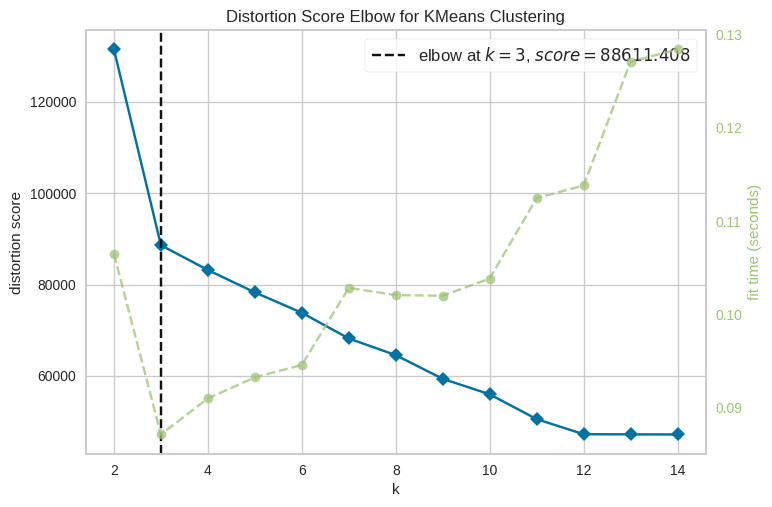

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [27]:
model = KMeans()
visualizer = KElbowVisualizer(model, k=(2,15), force_model=True)
visualizer.fit(X) 
visualizer.poof()

In [28]:
feature_encoder

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

For n_clusters = 2 The average silhouette_score is : 0.9905957593035606
For n_clusters = 3 The average silhouette_score is : 0.06126007723435878
For n_clusters = 4 The average silhouette_score is : 0.09254200567144952
For n_clusters = 5 The average silhouette_score is : 0.15322760320883932
For n_clusters = 6 The average silhouette_score is : 0.15450313720465803
For n_clusters = 7 The average silhouette_score is : 0.1579524415040751
For n_clusters = 8 The average silhouette_score is : 0.2184058537000636
For n_clusters = 9 The average silhouette_score is : 0.24916555059251858
For n_clusters = 10 The average silhouette_score is : 0.2157698854279504
For n_clusters = 11 The average silhouette_score is : 0.29343441100708184
For n_clusters = 12 The average silhouette_score is : 0.26306944133637633
For n_clusters = 13 The average silhouette_score is : 0.23028184286406148
For n_clusters = 14 The average silhouette_score is : 0.2337499367957603


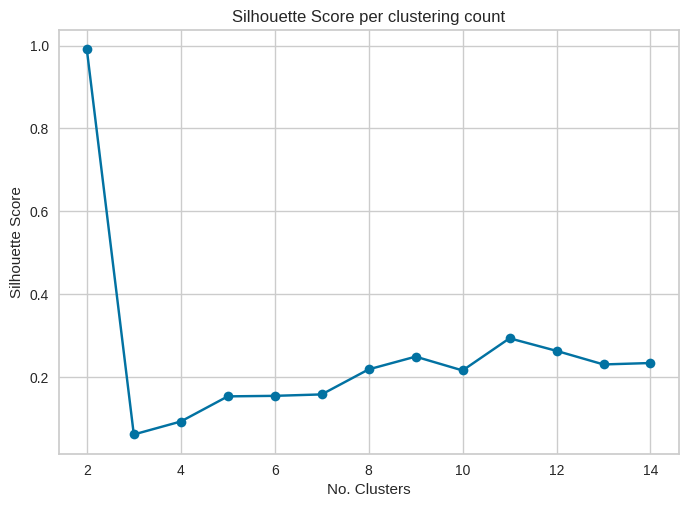

In [29]:
silhouette_s = []

for n_clusters in range(2, 10):
    cl_algo = KMeans(n_clusters=n_clusters)


    cluster_labels = cl_algo.fit_predict(X)
    print("For n_clusters =", n_clusters,"The average silhouette_score is :", silhouette_score(X, cluster_labels))
    silhouette_s.append(silhouette_score(X, cluster_labels))

plt.plot(range(2, 10),silhouette_s, "o-")
plt.xlabel("No. Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score per clustering count")
plt.show()

In [34]:
n_clusters = 2 # By Highest Sillouette Score

clusteringKmeans = KMeans(n_clusters=n_clusters, random_state=123)
clusteringKmeans.fit(X)
labels = clusteringKmeans.predict(X)


df_smaller["clusters"] = labels
#sns.scatterplot(data=df_smaller, x="Canada_Nominal_GDP", y="Switzerland_Nominal_GDP", hue="k-means3",palette='bright');

df_smaller.head()

,COUNTRY,INDICATOR,FREQUENCY,year,mev_value,mev_name,clusters
0,United Kingdom,"Current account balance (credit less debit), P...",Annual,2000,-1.831,Current Balance,1
1,Austria,"Current account balance (credit less debit), P...",Annual,2000,-0.710,Current Balance,1
2,G7,"Current account balance (credit less debit), P...",Annual,2000,-1.361,Current Balance,1
4,Advanced Economies,"Gross domestic product (GDP), Constant prices,...",Annual,2000,4.158,GDP,1
6,Advanced Economies,"All Items, Consumer price index (CPI), Period ...",Annual,2000,2.256,Inflation,1


<Axes: xlabel='clusters', ylabel='count'>

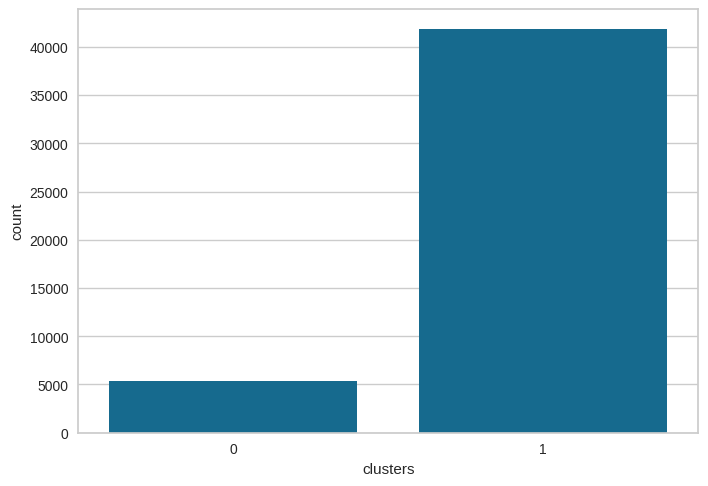

In [35]:
sns.countplot(data=df_smaller, x='clusters')

The idea behind this is to find rows in our data that behave similar to each other.

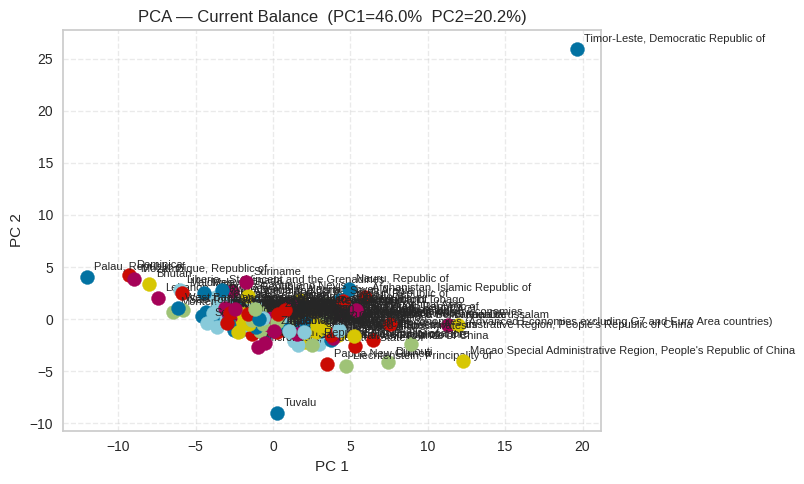

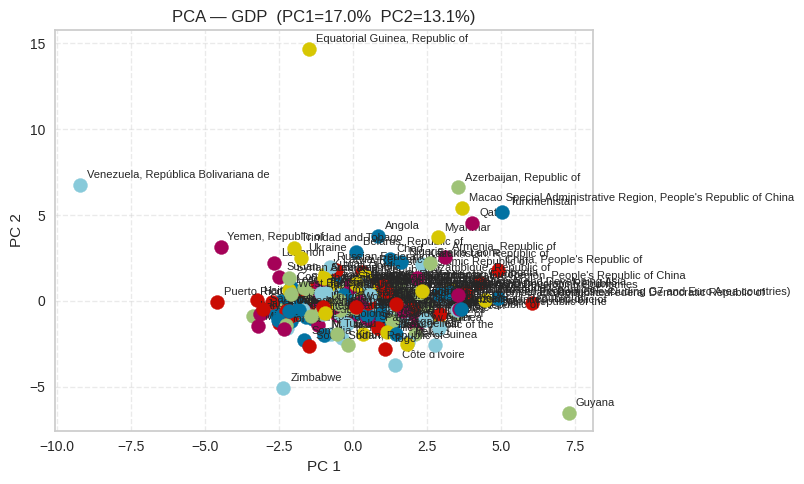

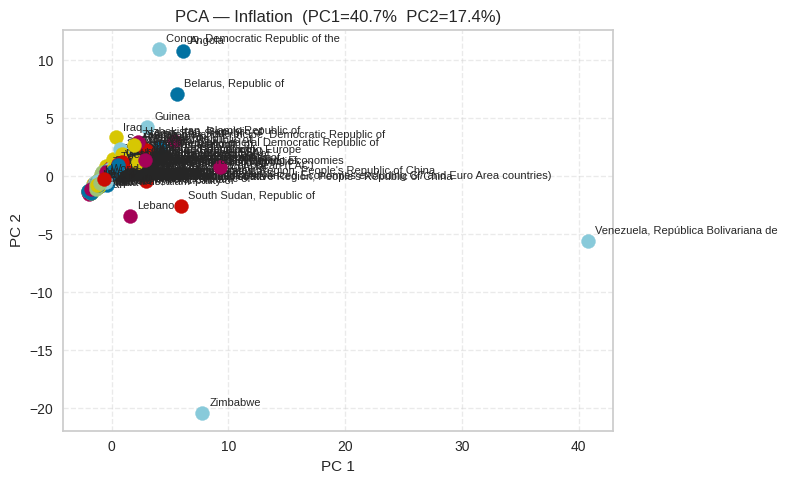

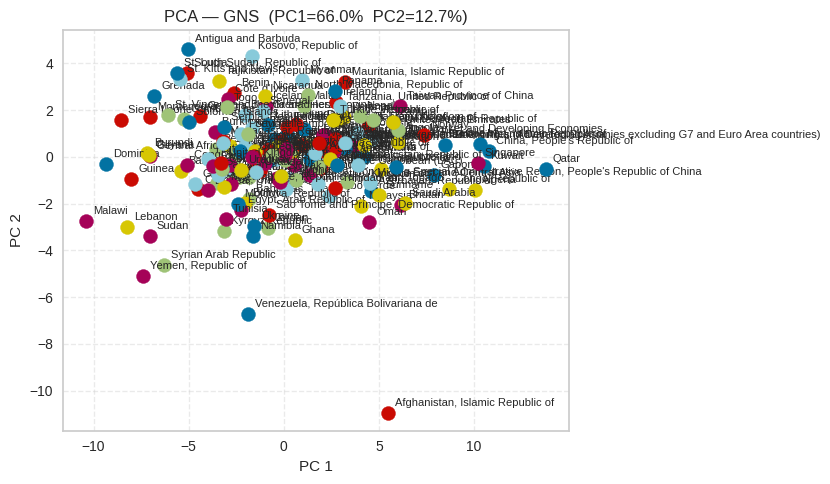

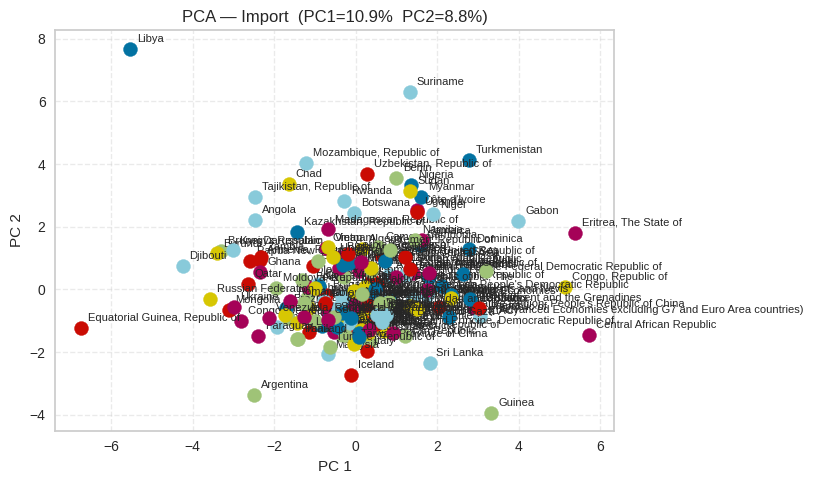

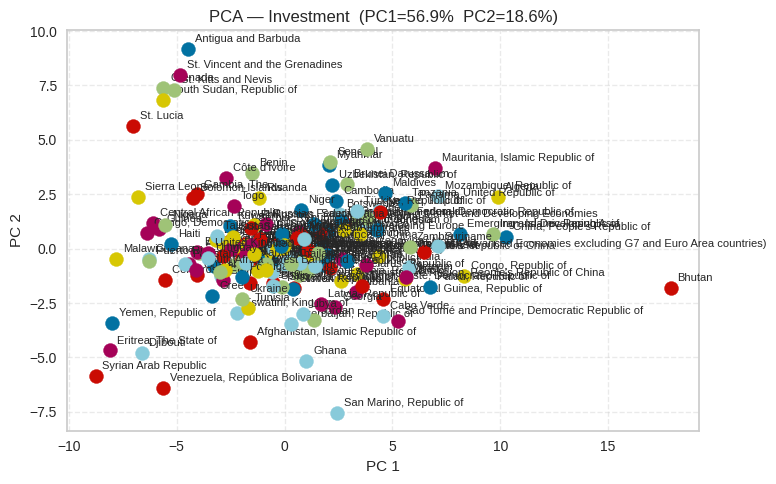

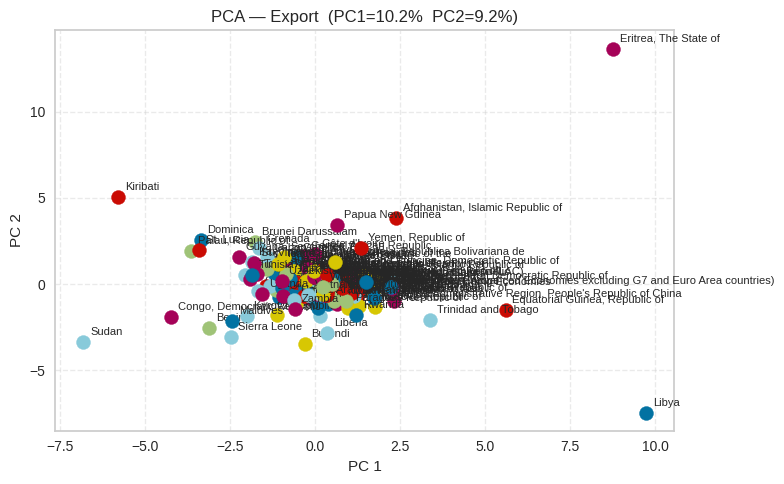

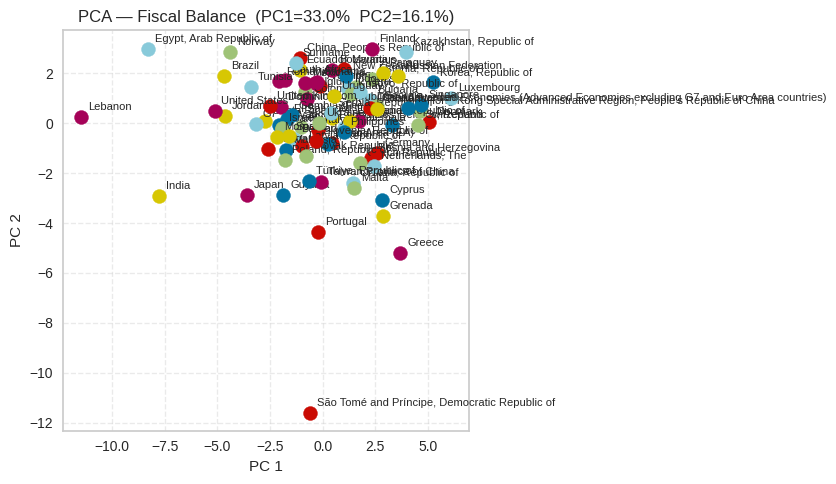

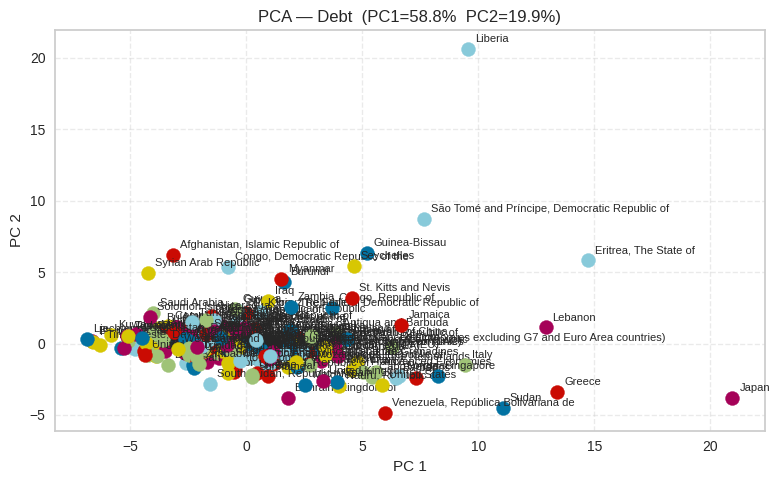

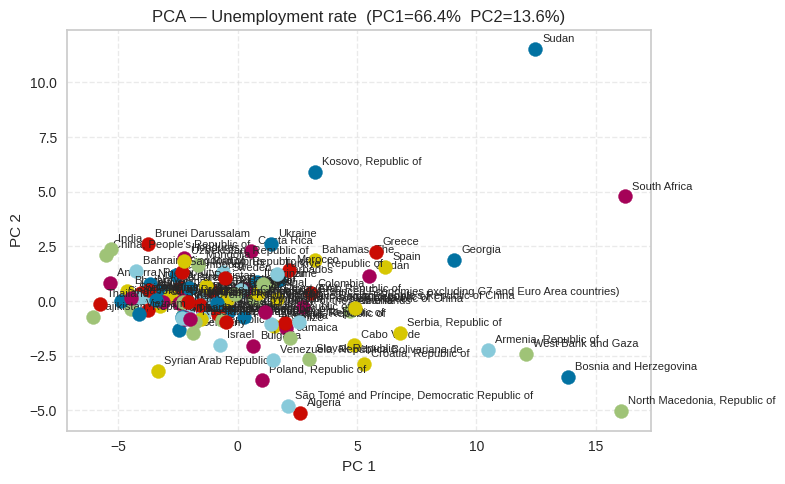

In [36]:
from sklearn.decomposition import PCA

vars_to_plot = df_smaller['mev_name'].unique()

for var in vars_to_plot:

    # Build country × year matrix
    pivot_T = pivots[var].T
    country_names = pivot_T.index.tolist()

    # Impute → Scale → PCA
    X_imp    = SimpleImputer(strategy='mean').fit_transform(pivot_T.values)
    X_scaled = StandardScaler().fit_transform(X_imp)

    pca    = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X_scaled)
    var_explained = pca.explained_variance_ratio_ * 100

    # KMeans labels
    lbls = KMeans(n_clusters=n_clusters, random_state=123).fit_predict(X_scaled)

    # Plot
    plt.figure(figsize=(8, 5))
    
    for i, country in enumerate(country_names):
        plt.scatter(coords[i, 0], coords[i, 1], s=100, zorder=3)
        plt.annotate(country, xy=(coords[i, 0], coords[i, 1]),
                     xytext=(5, 5), textcoords='offset points', fontsize=8)

    plt.title(f'PCA — {var}  (PC1={var_explained[0]:.1f}%  PC2={var_explained[1]:.1f}%)')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

In [37]:
for var in df_smaller['mev_name'].unique():

    # Transpose so countries are rows, years are columns
    pivot_T = pivots[var].T
    country_names = pivot_T.index.tolist()

    # Impute → Scale → KMeans
    X_imp    = SimpleImputer(strategy='mean').fit_transform(pivot_T.values)
    X_scaled = StandardScaler().fit_transform(X_imp)

    lbls = KMeans(n_clusters=n_clusters, random_state=123).fit_predict(X_scaled)

    # Attach cluster labels to a results dataframe
    cluster_df = pd.DataFrame({'country': country_names, 'Cluster': lbls})
    cluster_df = cluster_df.sort_values('Cluster').reset_index(drop=True)

    print(f"\n{'='*45}")
    print(f"  Variable: {var}")
    print(f"{'='*45}")
    print(cluster_df.to_string(index=False))


  Variable: Current Balance
                                                                           country  Cluster
                                                                Advanced Economies        0
                                                                           Albania        0
                                                               Antigua and Barbuda        0
                                                                         Argentina        0
                                                                      Bahamas, The        0
                                                                         Australia        0
                                                              Armenia, Republic of        0
                                                                           Burundi        0
                                                            Bosnia and Herzegovina        0
                                                   